# Level 2 Charging Infrastructure for Operationally Suited Fleet Vehicles

**DSC 680 Applied Data Science**  
**Dan Morrow**

This notebook builds on the operational-suitability analysis completed in the earlier fleet project. That analysis established the rules used to identify vehicle-days with operating patterns favorable for electrification. This project reapplies those rules to create the vehicle cohort used for charging infrastructure planning.

The new question is whether the selected vehicles can recover their estimated daily energy using the tested Level 2 charging configurations. The model estimates planning energy, required ports, screening feasibility, connected power, and cost. Results for all quality-eligible vehicles are retained as a comparison so the effect of focusing on operationally suitable vehicles can be measured directly.

The operational-suitability screen from the earlier project is reapplied to create the primary vehicle cohort. The charging model then estimates planning energy, required ports, screening feasibility, connected power, and cost for those vehicles. Results for all quality-eligible vehicles are retained as a comparison so the analysis can measure how focusing on operationally suitable vehicles changes the infrastructure results.

## Research Questions

1. How does focusing on operationally suitable vehicles change deployment-level energy demand and Level 2 charging feasibility compared with including all quality-eligible vehicles?
2. How much daily charging energy is required for the operationally suitable vehicles?
3. How many Level 2 charging ports are needed under different charger-power and charging-window assumptions?
4. What planning-level equipment and installation costs are associated with the lowest-cost feasible configuration under the 10-hour baseline?
5. How sensitive are the feasibility results to changes in the assumed energy use of the selected vehicles?

In [1]:
#Load libraries
from pathlib import Path
from urllib.request import Request, urlopen
import math
import shutil

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

#Set display and chart options
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180})

print("Output:")
print("Libraries and display options loaded.")

Output:
Libraries and display options loaded.


## Load the Data

The analysis uses the public Fleet DNA composite file. The loading cell first checks the notebook folder and its `data` subfolder. If the file isn't present, it attempts to download the official copy with a browser-style request header. If that request is blocked, download the file manually and place it in a folder named `data` beside the notebook.

Only the fields required for the operational screen, vehicle summaries, and charging model are loaded.

In [2]:
#Create local folders
data_dir = Path("data")
figure_dir = Path("figures_operationally_suited")
data_dir.mkdir(exist_ok=True)
figure_dir.mkdir(exist_ok=True)

#Use an existing local copy before attempting a download
candidate_paths = [
    data_dir / "fleet_dna_composite.csv",
    Path("fleet_dna_composite.csv")
]
data_path = next(
    (path for path in candidate_paths if path.exists() and path.stat().st_size > 1_000_000),
    None
)

if data_path is None:
    data_path = data_dir / "fleet_dna_composite.csv"
    data_url = "https://www.nlr.gov/media/docs/libraries/transportation/csv/data_for_fleet_dna_composite_data.csv"
    request = Request(
        data_url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "text/csv,*/*;q=0.8",
            "Referer": "https://www.nlr.gov/transportation/fleettest-fleet-dna"
        }
    )
    try:
        with urlopen(request) as response, data_path.open("wb") as destination:
            shutil.copyfileobj(response, destination)
    except Exception as error:
        raise RuntimeError(
            "The Fleet DNA download was blocked. Download the composite CSV manually, "
            "save it as data/fleet_dna_composite.csv, and rerun this cell."
        ) from error

#Load fields used by the suitability and infrastructure models
use_columns = [
    "vid", "did", "class_id", "voc_id", "day_id", "distance_total",
    "trip_count", "driving_data_duration_hrs", "driving_average_speed",
    "percent_zero", "total_stops", "stops_per_mile"
]
raw = pd.read_csv(data_path, usecols=use_columns, low_memory=False)

print("Output:")
print(f"Data file: {data_path}")
print(f"Vehicle-day records: {len(raw):,}")
print(f"Unique vehicles: {raw['vid'].nunique():,}")
print(f"Unique deployments: {raw['did'].nunique():,}")

Output:
Data file: data/fleet_dna_composite.csv
Vehicle-day records: 4,705
Unique vehicles: 486
Unique deployments: 57


## Data Quality and Preparation

Fleet DNA is organized by vehicle day. The review below checks every input used by the operational screen, rather than mileage alone. Duplicate vehicle-day records, missing values, and values outside basic logical ranges are reported before any filtering.

Vehicles need at least three recorded days so a planning percentile and majority-of-days suitability rule aren't based on only one or two observations. No model input is imputed.

In [3]:
#Define basic validity rules for every operational-screen input
input_rules = {
    "distance_total": lambda values: values.gt(0) & values.le(600),
    "driving_data_duration_hrs": lambda values: values.ge(0) & values.le(24),
    "driving_average_speed": lambda values: values.ge(0),
    "percent_zero": lambda values: values.between(0, 100),
    "stops_per_mile": lambda values: values.ge(0),
    "trip_count": lambda values: values.ge(0),
    "total_stops": lambda values: values.ge(0)
}

#Review completeness and logical validity
quality_rows = []
for field, rule in input_rules.items():
    missing = raw[field].isna()
    invalid = raw[field].notna() & ~rule(raw[field])
    quality_rows.append({
        "Field": field,
        "Missing values": int(missing.sum()),
        "Invalid values": int(invalid.sum())
    })

quality_summary = pd.DataFrame(quality_rows)
duplicate_count = int(raw.duplicated(["vid", "day_id"]).sum())

print("Output:")
print(f"Duplicate vehicle-day records: {duplicate_count:,}")
display(quality_summary)

Output:
Duplicate vehicle-day records: 0


,Field,Missing values,Invalid values
0,distance_total,0,0
1,driving_data_duration_hrs,0,0
2,driving_average_speed,0,0
3,percent_zero,0,0
4,stops_per_mile,0,0
5,trip_count,0,0
6,total_stops,0,0


## Reapply the Earlier Operational-Suitability Screen

The earlier fleet project established five rules for identifying vehicle-days with operating patterns favorable for electrification:

* Daily distance is between 20 and 120 miles.
* Driving time is eight hours or less.
* Average driving speed is 35 miles per hour or less.
* Zero-speed time is at least 30% or the vehicle makes at least one stop per mile.
* The route includes at least four trips and 30 stops.

These thresholds come from the earlier project. They weren’t selected because they are the most common values in Fleet DNA, and this notebook doesn’t create a new operational-suitability model. Instead, it reapplies the established rules so the charging infrastructure analysis uses the same definition of operational suitability.

A vehicle-day is classified as **High Suitability** when it meets at least four of the five rules.

The earlier project classified individual vehicle-days rather than entire vehicles. Charging infrastructure, however, must be planned around vehicles that consistently demonstrate suitable operating patterns. This notebook therefore adds one vehicle-level aggregation rule: a vehicle enters the primary charging cohort when **more than 50% of its recorded days** are classified as High Suitability.

The 50% threshold is a simple majority rule created for this infrastructure analysis. It isn’t a learned cutoff or an industry standard. It requires favorable operation to be the vehicle’s usual pattern instead of allowing one unusually favorable day to determine whether the vehicle is included.


In [4]:
#Remove duplicate records and rows that fail a required input rule
clean = raw.drop_duplicates(["vid", "day_id"]).copy()
valid_row = pd.Series(True, index=clean.index)
for field, rule in input_rules.items():
    valid_row &= clean[field].notna() & rule(clean[field])
clean = clean[valid_row].copy()

#Recreate the five rules from the earlier project
clean["manageable_distance"] = clean["distance_total"].between(20, 120).astype(int)
clean["moderate_driving_time"] = clean["driving_data_duration_hrs"].le(8).astype(int)
clean["local_speed_pattern"] = clean["driving_average_speed"].le(35).astype(int)
clean["stop_go_pattern"] = (
    clean["percent_zero"].ge(30) | clean["stops_per_mile"].ge(1)
).astype(int)
clean["active_route"] = (
    clean["trip_count"].ge(4) & clean["total_stops"].ge(30)
).astype(int)

score_columns = [
    "manageable_distance", "moderate_driving_time", "local_speed_pattern",
    "stop_go_pattern", "active_route"
]
clean["ev_suitability_score"] = clean[score_columns].sum(axis=1)
clean["high_suitability_day"] = clean["ev_suitability_score"].ge(4)

#Map vocation codes to readable labels
vocation_map = {
    1: "Telecom", 2: "Beverage delivery", 3: "Warehouse delivery",
    4: "Parcel delivery", 5: "School bus", 6: "Linen delivery",
    7: "Refuse pickup", 8: "Long haul", 10: "Mass transit",
    11: "Towing", 12: "Grocery delivery", 13: "Port drayage",
    14: "Food delivery", 15: "Snow plow", 16: "Utility",
    18: "Local delivery"
}
clean["vocation"] = clean["voc_id"].map(vocation_map)

#Summarize each vehicle using all usable days
vehicle_summary_all = (
    clean.groupby(["did", "vid"], as_index=False)
    .agg(
        class_id=("class_id", "first"),
        vocation=("vocation", "first"),
        recorded_days=("day_id", "nunique"),
        high_suitability_days=("high_suitability_day", "sum"),
        high_suitability_share=("high_suitability_day", "mean"),
        median_suitability_score=("ev_suitability_score", "median"),
        median_daily_miles=("distance_total", "median"),
        p90_daily_miles=("distance_total", lambda values: values.quantile(0.90)),
        maximum_daily_miles=("distance_total", "max")
    )
)

#Require enough history for a vehicle-level planning percentile
excluded_short_history = int(vehicle_summary_all["recorded_days"].lt(3).sum())
vehicle_summary_all = vehicle_summary_all[
    vehicle_summary_all["recorded_days"].ge(3)
].copy()

#Select vehicles whose usual recorded pattern is High Suitability
vehicle_summary = vehicle_summary_all[
    vehicle_summary_all["high_suitability_share"].gt(0.50)
].copy()

print("Output:")
print(f"Usable vehicle-day records: {len(clean):,}")
print(f"High Suitability vehicle-days: {clean['high_suitability_day'].sum():,} ({100 * clean['high_suitability_day'].mean():.1f}%)")
print(f"Vehicles retained after the three-day rule: {len(vehicle_summary_all):,}")
print(f"Vehicles excluded for fewer than three days: {excluded_short_history:,}")
print(f"Vehicles in the operationally suited cohort: {len(vehicle_summary):,}")
print(f"Primary-cohort deployments: {vehicle_summary['did'].nunique():,}")

Output:
Usable vehicle-day records: 4,705
High Suitability vehicle-days: 3,481 (74.0%)
Vehicles retained after the three-day rule: 433
Vehicles excluded for fewer than three days: 53
Vehicles in the operationally suited cohort: 373
Primary-cohort deployments: 53


The primary cohort will be used for the main charging infrastructure analysis. The 60 quality-eligible vehicles that don’t meet the vehicle-level majority rule remain in the broader comparison group. This allows the analysis to measure how focusing on operationally suitable vehicles changes deployment-level energy demand and Level 2 screening feasibility.

Four deployments don’t contain any vehicles that meet the majority rule, so they aren’t included in the primary charging analysis. This doesn’t mean those deployments can never be electrified. It only means their recorded vehicles didn’t consistently meet the operational criteria established in the earlier project.

Charging demand for each selected vehicle is calculated from **all of its usable recorded days**, not only its High Suitability days. This preserves higher-mileage and more demanding days after a vehicle is selected and prevents the infrastructure requirements from being based only on favorable operating conditions.

### Key Fields

| Field                    | Role in the analysis                                                       |
| ------------------------ | -------------------------------------------------------------------------- |
| `vid`                    | Anonymous vehicle identifier                                               |
| `did`                    | Anonymous deployment identifier                                            |
| `day_id`                 | Recorded operating day                                                     |
| `ev_suitability_score`   | Number of earlier operational-suitability rules met on a vehicle-day       |
| `high_suitability_share` | Share of a vehicle’s recorded days meeting at least four suitability rules |
| `class_id`               | Assigns the class-level energy-use factor                                  |
| `vocation`               | Supports comparisons across fleet use cases                                |
| `distance_total`         | Used in both the inherited suitability screen and the energy calculation   |
| `p90_daily_miles`        | Planning mileage calculated from all usable days for a selected vehicle    |
| `planning_grid_kwh`      | Estimated electricity the vehicle would draw from the site                 |


## Model Design and Assumptions

This is a deterministic scenario model: the same inputs always produce the same result. It fits the question because Fleet DNA contains operating data but not completed depot projects with observed charger choices and construction costs. A predictive model therefore has no historical outcome to learn. A Monte Carlo model would require defensible probability distributions for schedules, energy use, and site costs; those distributions aren't available here. The scenario approach keeps every assumption visible and uses sensitivity analysis to show how uncertainty affects the answer.

Each selected vehicle's 90th-percentile mileage is converted to grid electricity with a class-level energy factor and 90% charging efficiency. The 90th percentile represents demanding days without allowing one maximum observation to set the design. The class-level factors are planning assumptions informed by AFLEET's vehicle-class framework; they aren't energy measurements from Fleet DNA. The next cell displays each factor so its effect on the model can be reviewed directly.

The 7.2-, 11.5-, and 19.2-kilowatt values are lower, intermediate, and higher Level 2 planning points. They aren't observed in Fleet DNA and aren't presented as the three most common commercial chargers. The 8-, 10-, and 12-hour windows represent restrictive, midpoint, and flexible overnight availability because Fleet DNA doesn't include complete depot arrival and departure schedules. Ten hours is the midpoint baseline, not an observed average. The model treats 85% of each window as usable to allow for switching, delays, and interruptions.

A scenario must supply the deployment's total planning energy, support its highest-demand vehicle, and require no more ports than vehicles. In this notebook, **screening feasible** means that a deployment passes those three aggregate rules. It doesn't prove that every vehicle can be assigned to an available port at the correct time because the model doesn't build a vehicle-by-vehicle charging schedule. Actual feasibility still requires confirmed schedules, parking access, and a site-specific charging plan. Equipment and installation amounts are editable planning values, not vendor quotes.

In [5]:
#Document model assumptions and why each was selected
class_efficiency = {
    2: 0.55, 3: 0.70, 4: 0.90, 5: 1.10,
    6: 1.30, 7: 1.70, 8: 2.10
}
charger_equipment = {7.2: 2000, 11.5: 3500, 19.2: 5000}
installation_cost = {"Low": 600, "Typical": 2500, "High": 12700}
charging_windows = [8, 10, 12]
charging_efficiency = 0.90
scheduling_factor = 0.85
annual_maintenance_per_port = 400

class_efficiency_table = pd.DataFrame({
    "Vehicle class": [f"Class {class_id}" for class_id in class_efficiency],
    "Planning energy factor (kWh/mile)": list(class_efficiency.values()),
    "Selection basis": [
        "Planning assumption informed by the AFLEET class framework"
    ] * len(class_efficiency)
})

assumptions = pd.DataFrame([
    ["Vehicle cohort", ">50% of recorded days are High Suitability", "Analyst-defined majority rule"],
    ["High Suitability day", "At least 4 of 5 operational rules", "Earlier fleet project"],
    ["Planning mileage", "Vehicle-level 90th percentile", "Demanding-day planning value"],
    ["Charging efficiency", "90%", "Planning assumption; tested through sensitivity"],
    ["Usable charging time", "85% of stated window", "Allowance for operational interruptions"],
    ["Charger power", "7.2, 11.5, and 19.2 kW", "Lower, middle, and upper Level 2 scenarios"],
    ["Charging windows", "8, 10, and 12 hours", "Restrictive, midpoint, and flexible scenarios"],
    ["Baseline", "10 hours", "Midpoint scenario; not observed in Fleet DNA"],
    ["Equipment per port", "USD 2,000 to USD 5,000", "Editable planning range by power"],
    ["Installation per port", "USD 600 / USD 2,500 / USD 12,700", "Low, typical, and high planning cases"],
    ["Annual maintenance", "USD 400 per port", "Separate planning assumption"]
], columns=["Assumption", "Value", "Selection basis"])

print("Output:")
print("Class-level energy factors:")
display(class_efficiency_table)
print("Other model assumptions:")
display(assumptions)

Output:
Class-level energy factors:


,Vehicle class,Planning energy factor (kWh/mile),Selection basis
0,Class 2,0.55,Planning assumption informed by the AFLEET cla...
1,Class 3,0.70,Planning assumption informed by the AFLEET cla...
2,Class 4,0.90,Planning assumption informed by the AFLEET cla...
3,Class 5,1.10,Planning assumption informed by the AFLEET cla...
4,Class 6,1.30,Planning assumption informed by the AFLEET cla...
5,Class 7,1.70,Planning assumption informed by the AFLEET cla...
6,Class 8,2.10,Planning assumption informed by the AFLEET cla...


Other model assumptions:


,Assumption,Value,Selection basis
0,Vehicle cohort,>50% of recorded days are High Suitability,Analyst-defined majority rule
1,High Suitability day,At least 4 of 5 operational rules,Earlier fleet project
2,Planning mileage,Vehicle-level 90th percentile,Demanding-day planning value
3,Charging efficiency,90%,Planning assumption; tested through sensitivity
4,Usable charging time,85% of stated window,Allowance for operational interruptions
5,Charger power,"7.2, 11.5, and 19.2 kW","Lower, middle, and upper Level 2 scenarios"
6,Charging windows,"8, 10, and 12 hours","Restrictive, midpoint, and flexible scenarios"
7,Baseline,10 hours,Midpoint scenario; not observed in Fleet DNA
8,Equipment per port,"USD 2,000 to USD 5,000",Editable planning range by power
9,Installation per port,"USD 600 / USD 2,500 / USD 12,700","Low, typical, and high planning cases"


## Build the Charging Scenarios

The same formulas are run twice: once for the operationally suited primary cohort and once for all vehicles that pass the three-day quality rule. This comparison isolates how the operational screen changes the charging result.

Required ports equal total deployment energy divided by the effective energy from one port, rounded up. Effective energy per port equals charger power multiplied by the charging window and the 85% usable-time factor.

In [6]:
#Convert vehicle mileage to estimated grid energy
def add_energy_requirements(vehicle_data):
    result = vehicle_data.copy()
    result["kwh_per_mile"] = result["class_id"].map(class_efficiency)
    result["typical_grid_kwh"] = (
        result["median_daily_miles"] * result["kwh_per_mile"] / charging_efficiency
    )
    result["planning_grid_kwh"] = (
        result["p90_daily_miles"] * result["kwh_per_mile"] / charging_efficiency
    )
    return result


#Combine vehicle requirements into deployment requirements
def summarize_deployments(vehicle_data):
    return (
        vehicle_data.groupby("did", as_index=False)
        .agg(
            vehicle_count=("vid", "nunique"),
            vocation=("vocation", lambda values: values.mode().iloc[0]),
            dominant_class=("class_id", lambda values: int(values.mode().iloc[0])),
            recorded_vehicle_days=("recorded_days", "sum"),
            typical_grid_kwh=("typical_grid_kwh", "sum"),
            planning_grid_kwh=("planning_grid_kwh", "sum"),
            maximum_vehicle_grid_kwh=("planning_grid_kwh", "max"),
            median_vehicle_p90_miles=("p90_daily_miles", "median"),
            maximum_daily_miles=("maximum_daily_miles", "max")
        )
    )


#Build every charger, window, and installation-complexity scenario
def build_scenarios(deployment_data):
    rows = []
    for deployment in deployment_data.itertuples(index=False):
        for window_hours in charging_windows:
            for charger_kw, equipment_per_port in charger_equipment.items():
                effective_port_kwh = charger_kw * window_hours * scheduling_factor
                required_ports = math.ceil(
                    deployment.planning_grid_kwh / effective_port_kwh
                )
                individual_vehicle_ok = (
                    deployment.maximum_vehicle_grid_kwh <= effective_port_kwh
                )
                feasible = individual_vehicle_ok and required_ports <= deployment.vehicle_count

                for complexity, installation_per_port in installation_cost.items():
                    total_cost = required_ports * (
                        equipment_per_port + installation_per_port
                    )
                    rows.append({
                        "did": int(deployment.did),
                        "vocation": deployment.vocation,
                        "vehicle_count": int(deployment.vehicle_count),
                        "planning_grid_kwh": deployment.planning_grid_kwh,
                        "window_hours": window_hours,
                        "charger_kw": charger_kw,
                        "effective_port_kwh": effective_port_kwh,
                        "required_ports": required_ports,
                        "individual_vehicle_ok": individual_vehicle_ok,
                        "feasible": feasible,
                        "complexity": complexity,
                        "equipment_cost": required_ports * equipment_per_port,
                        "installation_cost": required_ports * installation_per_port,
                        "total_cost": total_cost,
                        "cost_per_vehicle": total_cost / deployment.vehicle_count,
                        "connected_kw": required_ports * charger_kw,
                        "annual_maintenance": required_ports * annual_maintenance_per_port
                    })
    return pd.DataFrame(rows)


vehicle_summary_all = add_energy_requirements(vehicle_summary_all)
vehicle_summary = add_energy_requirements(vehicle_summary)
deployment_summary_all = summarize_deployments(vehicle_summary_all)
deployment_summary = summarize_deployments(vehicle_summary)
scenarios_all = build_scenarios(deployment_summary_all)
scenarios = build_scenarios(deployment_summary)

print("Output:")
print(f"Primary scenario rows: {len(scenarios):,}")
print(f"Primary deployment/power/window combinations: {scenarios[['did', 'window_hours', 'charger_kw']].drop_duplicates().shape[0]:,}")

Output:
Primary scenario rows: 1,431
Primary deployment/power/window combinations: 477


## Select and Compare the 10-Hour Baseline

For each deployment, the baseline keeps the lowest-cost feasible option under the 10-hour window and typical installation assumption. If options have the same cost, the model selects less connected power. A deployment without a feasible tested option remains constrained.

The comparison below separates three effects:

- deployments removed because none of their vehicles pass the operational screen,
- retained deployments whose status changes after nonselected vehicles are removed, and
- the change in the feasibility denominator.

In [7]:
#Select the lowest-cost feasible baseline option for each deployment
def select_baseline(scenario_data, deployment_data):
    candidates = scenario_data[
        scenario_data["window_hours"].eq(10)
        & scenario_data["complexity"].eq("Typical")
        & scenario_data["feasible"]
    ].copy()

    best = (
        candidates
        .sort_values(["did", "total_cost", "connected_kw", "charger_kw"])
        .groupby("did", as_index=False)
        .first()
    )

    cost_range = (
        scenario_data[
            scenario_data["window_hours"].eq(10)
            & scenario_data["feasible"]
            & scenario_data["complexity"].isin(["Low", "High"])
        ][["did", "charger_kw", "complexity", "total_cost"]]
        .pivot_table(
            index=["did", "charger_kw"], columns="complexity",
            values="total_cost", aggfunc="first"
        )
        .reset_index()
        .rename(columns={"Low": "low_cost", "High": "high_cost"})
    )

    best = best.merge(cost_range, on=["did", "charger_kw"], how="left")
    best["low_cost_per_vehicle"] = best["low_cost"] / best["vehicle_count"]
    best["high_cost_per_vehicle"] = best["high_cost"] / best["vehicle_count"]

    deployment_result = deployment_data.copy()
    deployment_result["baseline_feasible"] = deployment_result["did"].isin(best["did"])
    return best, deployment_result


baseline_best, deployment_summary = select_baseline(scenarios, deployment_summary)
baseline_best_all, deployment_summary_all = select_baseline(
    scenarios_all, deployment_summary_all
)

#Summarize the focused and broader populations
cohort_comparison = pd.DataFrame({
    "Measure": [
        "Vehicles", "Deployments", "Median planning grid energy (kWh)",
        "10-hour feasible deployments", "10-hour feasibility (%)",
        "Median required ports among feasible deployments",
        "Median typical upfront cost among feasible deployments",
        "Median cost per vehicle among feasible deployments"
    ],
    "Operationally Suited Cohort": [
        len(vehicle_summary), len(deployment_summary),
        deployment_summary["planning_grid_kwh"].median(), len(baseline_best),
        100 * len(baseline_best) / len(deployment_summary),
        baseline_best["required_ports"].median(),
        baseline_best["total_cost"].median(),
        baseline_best["cost_per_vehicle"].median()
    ],
    "All Quality-Eligible Vehicles": [
        len(vehicle_summary_all), len(deployment_summary_all),
        deployment_summary_all["planning_grid_kwh"].median(), len(baseline_best_all),
        100 * len(baseline_best_all) / len(deployment_summary_all),
        baseline_best_all["required_ports"].median(),
        baseline_best_all["total_cost"].median(),
        baseline_best_all["cost_per_vehicle"].median()
    ]
})

print("Output:")
display(cohort_comparison)

Output:


,Measure,Operationally Suited Cohort,All Quality-Eligible Vehicles
0,Vehicles,373.00,433.00
1,Deployments,53.00,57.00
2,Median planning grid energy (kWh),353.12,464.96
3,10-hour feasible deployments,34.00,34.00
4,10-hour feasibility (%),64.15,59.65
5,Median required ports among feasible deployments,2.00,2.00
6,Median typical upfront cost among feasible dep...,"15,000.00","15,000.00"
7,Median cost per vehicle among feasible deploym...,"4,500.00","4,500.00"


In [8]:
#Show deployment membership and feasibility changes caused by the screen
all_view = deployment_summary_all[[
    "did", "vocation", "vehicle_count", "planning_grid_kwh", "baseline_feasible"
]].rename(columns={
    "vehicle_count": "all_vehicle_count",
    "planning_grid_kwh": "all_planning_kwh",
    "baseline_feasible": "all_feasible"
})

primary_view = deployment_summary[[
    "did", "vehicle_count", "planning_grid_kwh", "baseline_feasible"
]].rename(columns={
    "vehicle_count": "selected_vehicle_count",
    "planning_grid_kwh": "selected_planning_kwh",
    "baseline_feasible": "selected_feasible"
})

deployment_change = all_view.merge(primary_view, on="did", how="left")
deployment_change["primary_membership"] = np.where(
    deployment_change["selected_vehicle_count"].isna(), "Excluded", "Retained"
)
deployment_change["status_change"] = np.select(
    [
        deployment_change["primary_membership"].eq("Excluded"),
        deployment_change["all_feasible"].ne(deployment_change["selected_feasible"])
    ],
    ["Removed from primary cohort", "Feasibility changed"],
    default="No feasibility change"
)

changed_deployments = deployment_change[
    deployment_change["status_change"].ne("No feasibility change")
].copy()
changed_deployments["all_status"] = np.where(
    changed_deployments["all_feasible"], "Feasible", "Constrained"
)
changed_deployments["selected_status"] = np.where(
    changed_deployments["selected_feasible"].isna(),
    "Not in primary cohort",
    np.where(changed_deployments["selected_feasible"], "Feasible", "Constrained")
)

display_columns = [
    "did", "vocation", "status_change", "all_vehicle_count",
    "selected_vehicle_count", "all_planning_kwh", "selected_planning_kwh",
    "all_status", "selected_status"
]

print("Output:")
print("Deployments removed from the primary cohort or changed by the screen:")
display(changed_deployments[display_columns].sort_values("did"))

Output:
Deployments removed from the primary cohort or changed by the screen:


,did,vocation,status_change,all_vehicle_count,selected_vehicle_count,all_planning_kwh,selected_planning_kwh,all_status,selected_status
13,13,Food delivery,Removed from primary cohort,2,NaN,"1,633.58",NaN,Constrained,Not in primary cohort
23,26,Local delivery,Removed from primary cohort,3,NaN,992.89,NaN,Constrained,Not in primary cohort
24,27,Utility,Removed from primary cohort,2,NaN,236.13,NaN,Feasible,Not in primary cohort
44,50,Linen delivery,Feasibility changed,3,2.00,424.94,232.60,Constrained,Feasible
53,59,Beverage delivery,Removed from primary cohort,2,NaN,599.12,NaN,Constrained,Not in primary cohort


The operational screen reduces the primary sample from **57 to 53 deployments** because Deployments 13, 26, 27, and 59 have no selected vehicles. Deployment 27 was feasible in the broader analysis, so its removal subtracts one feasible deployment from the primary cohort. Among retained deployments, Deployment 50 changes from constrained to feasible after the vehicle count falls from three to two and planning demand falls from about 424.9 to 232.6 kWh.

The two effects offset each other, leaving **34 feasible deployments in both analyses**. The primary rate is higher because the denominator is smaller: **34 of 53 (64.2%)** compared with **34 of 57 (59.6%)**. The screen changes who is analyzed and one retained deployment's status; it doesn't create four additional feasible projects.

The primary cohort also has lower median planning energy. That difference is useful for describing the selected population, but it isn't independent proof that the screen works: daily distance appears in both the suitability rule and the energy calculation, so part of the reduction is expected by design.

## Results

### Planning Mileage by Vocation

Operationally suited vehicles still have different planning needs across vocations. Passing the screen doesn't mean every vehicle has the same mileage or energy requirement.

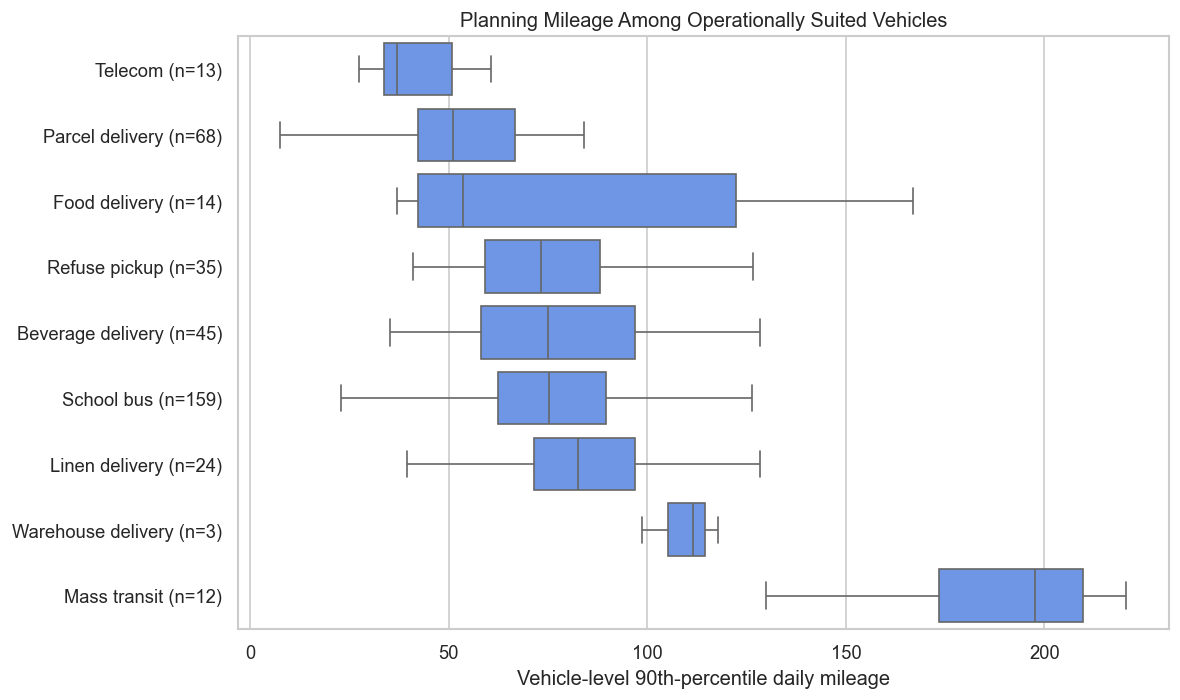

In [9]:
#Compare planning mileage across primary-cohort vocations
vocation_order = (
    vehicle_summary.groupby("vocation")["p90_daily_miles"]
    .median().sort_values().index
)
vocation_counts = vehicle_summary["vocation"].value_counts()
vocation_labels = {
    vocation: f"{vocation} (n={vocation_counts[vocation]})"
    for vocation in vocation_order
}
vehicle_plot = vehicle_summary.copy()
vehicle_plot["vocation_label"] = vehicle_plot["vocation"].map(vocation_labels)
label_order = [vocation_labels[vocation] for vocation in vocation_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=vehicle_plot, y="vocation_label", x="p90_daily_miles",
    order=label_order, color="#5B8FF9", showfliers=False, ax=ax
)
ax.set_title("Planning Mileage Among Operationally Suited Vehicles")
ax.set_xlabel("Vehicle-level 90th-percentile daily mileage")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(figure_dir / "01_operationally_suited_mileage_by_vocation.png", bbox_inches="tight")
plt.show()

The 53 primary-cohort deployments require an estimated **36.5 to 9,873.4 kWh per day**, with a median of **353.1 kWh**. The range shows why operational suitability and charging feasibility must remain separate decisions. The vocation labels include the number of selected vehicles so categories with smaller samples can be interpreted cautiously.

### Fleet Size and Charging Demand

Fleet size matters, but it doesn't determine energy demand by itself. Vehicle class and planning mileage can make a smaller deployment more energy-intensive than a larger one. The full-scale view preserves the largest deployments, while the detailed view makes the main cluster easier to compare.

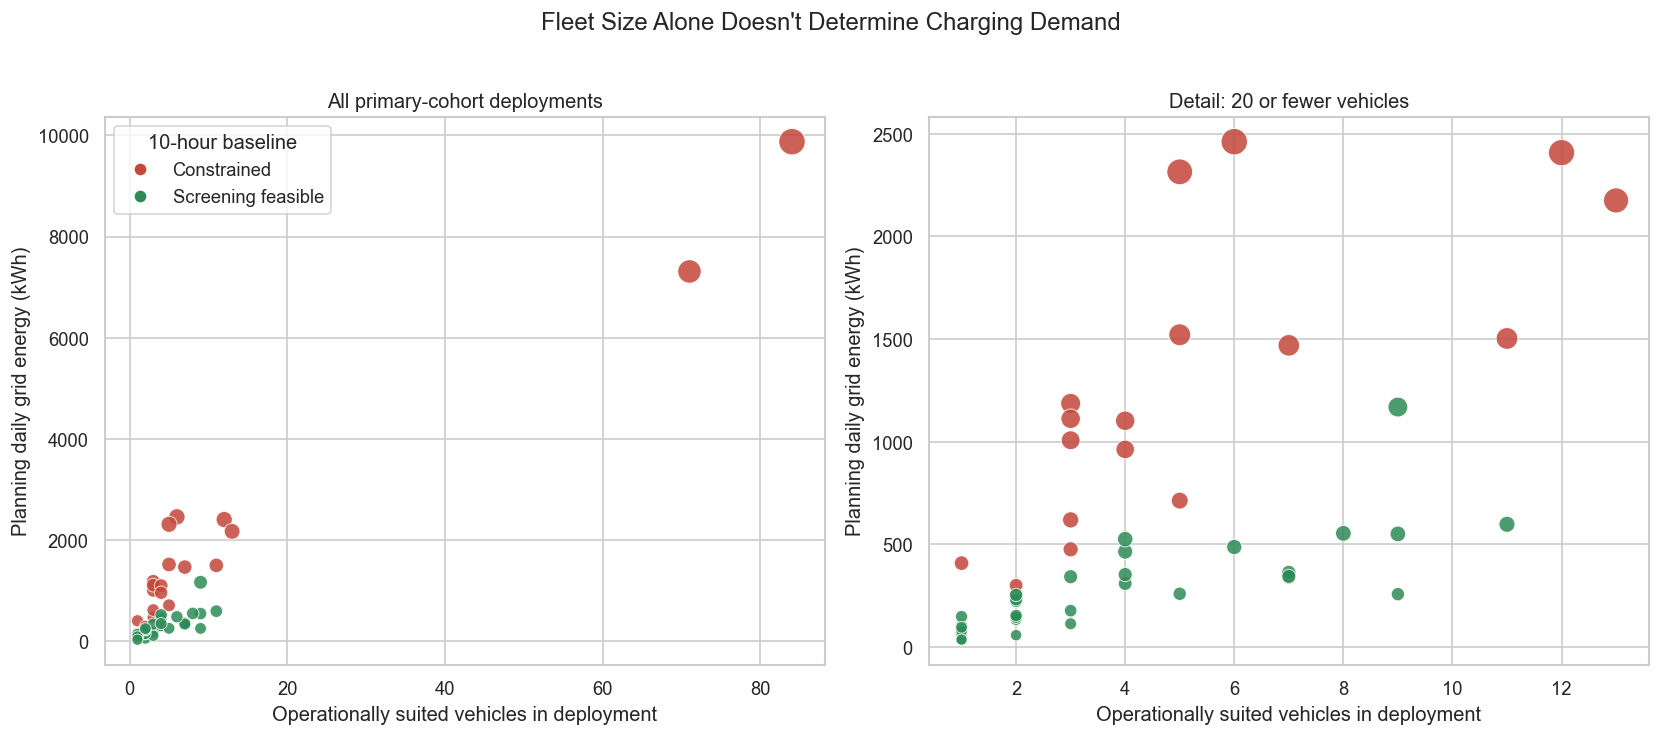

In [10]:
#Compare fleet size with planning energy at two useful scales
detail_limit = 20
detail_data = deployment_summary[deployment_summary["vehicle_count"].le(detail_limit)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, plot_data, title in [
    (axes[0], deployment_summary, "All primary-cohort deployments"),
    (axes[1], detail_data, f"Detail: {detail_limit} or fewer vehicles")
]:
    sns.scatterplot(
        data=plot_data, x="vehicle_count", y="planning_grid_kwh",
        hue="baseline_feasible", palette={True: "#2E8B57", False: "#C4473A"},
        size="planning_grid_kwh", sizes=(45, 250), alpha=0.85,
        legend=False, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Operationally suited vehicles in deployment")
    ax.set_ylabel("Planning daily grid energy (kWh)")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="Constrained", markerfacecolor="#C4473A", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="Screening feasible", markerfacecolor="#2E8B57", markersize=8)
]
axes[0].legend(handles=legend_handles, title="10-hour baseline", loc="upper left")
fig.suptitle("Fleet Size Alone Doesn't Determine Charging Demand", y=1.02)
fig.tight_layout()
fig.savefig(figure_dir / "02_operationally_suited_energy_by_fleet_size.png", bbox_inches="tight")
plt.show()

### Level 2 Screening Feasibility

Screening feasibility improves as charger power or charging time increases. A constrained result doesn't reverse the operational-suitability decision. It means the tested Level 2 configuration can't satisfy the calculated energy requirement within the stated planning rules.

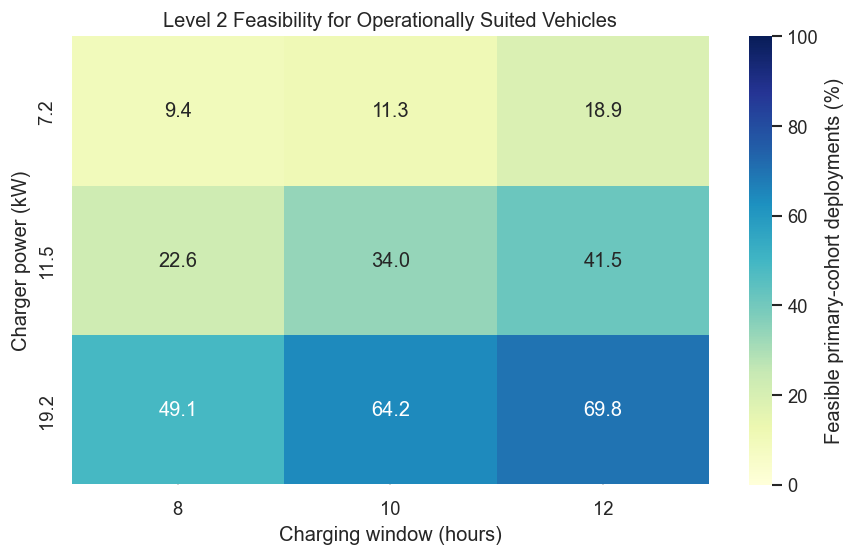

In [11]:
#Calculate feasible share for each primary-cohort configuration
feasibility_matrix = (
    scenarios[scenarios["complexity"].eq("Typical")]
    .groupby(["charger_kw", "window_hours"])["feasible"]
    .mean().mul(100).unstack()
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.heatmap(
    feasibility_matrix, annot=True, fmt=".1f", cmap="YlGnBu",
    vmin=0, vmax=100,
    cbar_kws={"label": "Feasible primary-cohort deployments (%)"}, ax=ax
)
ax.set_title("Level 2 Feasibility for Operationally Suited Vehicles")
ax.set_xlabel("Charging window (hours)")
ax.set_ylabel("Charger power (kW)")
fig.tight_layout()
fig.savefig(figure_dir / "03_operationally_suited_feasibility_heatmap.png", bbox_inches="tight")
plt.show()

At 19.2 kilowatts, extending the charging window from 8 to 12 hours increases estimated screening feasibility from **49.1% to 69.8%**. Under the 10-hour baseline, the lowest-cost feasible selections include 3 deployments at 7.2 kilowatts, 5 at 11.5 kilowatts, and 26 at 19.2 kilowatts. Those counts are outputs from the tested scenarios, not evidence that 19.2-kilowatt chargers are the most common market choice.

### Infrastructure Cost per Vehicle

The chart ranks the ten lowest-cost feasible primary-cohort deployments by modeled cost per vehicle. Each line shows the low-to-high installation range, while the dot marks the typical installation case.

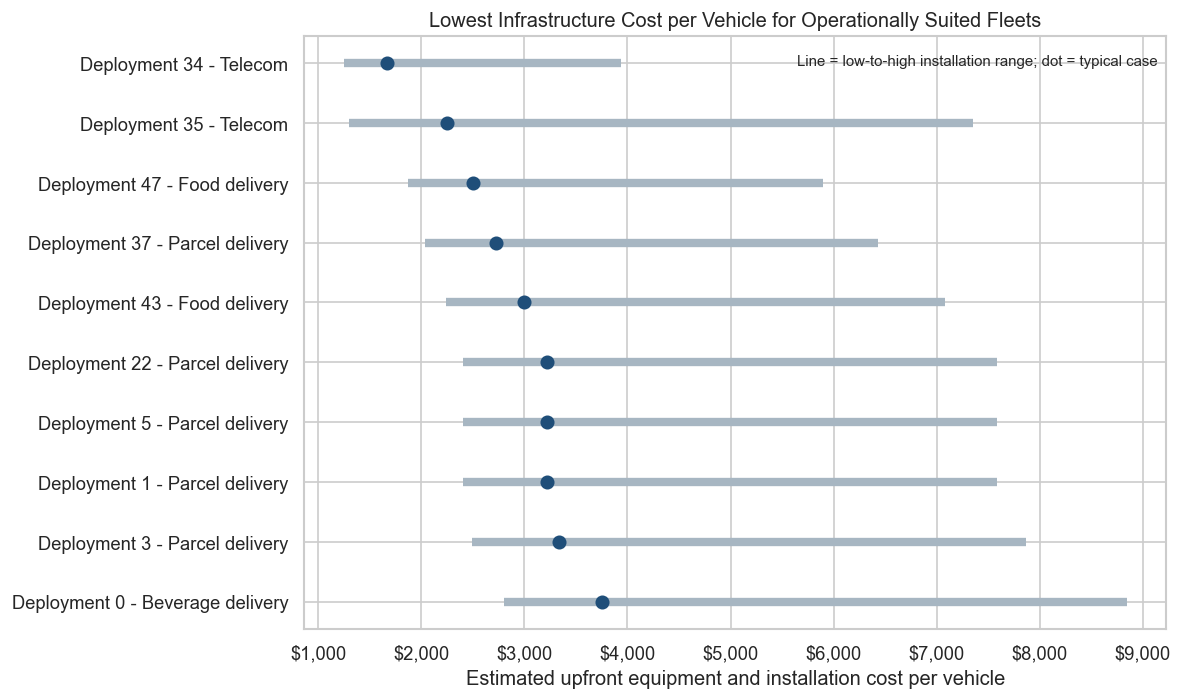

In [12]:
#Plot the ten lowest-cost primary-cohort deployments per vehicle
ranked = baseline_best.nsmallest(10, "cost_per_vehicle").copy()
ranked["label"] = ranked.apply(
    lambda row: f"Deployment {int(row['did'])} - {row['vocation']}", axis=1
)
ranked = ranked.sort_values("cost_per_vehicle", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
for y, row in enumerate(ranked.itertuples(index=False)):
    ax.hlines(
        y, row.low_cost_per_vehicle, row.high_cost_per_vehicle,
        color="#A7B6C2", linewidth=5
    )
    ax.scatter(row.cost_per_vehicle, y, color="#1F4E79", s=55, zorder=3)

ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(ranked["label"])
ax.set_title("Lowest Infrastructure Cost per Vehicle for Operationally Suited Fleets")
ax.set_xlabel("Estimated upfront equipment and installation cost per vehicle")
ax.xaxis.set_major_formatter(lambda value, position: f"${value:,.0f}")
ax.text(
    0.99, 0.97, "Line = low-to-high installation range; dot = typical case",
    transform=ax.transAxes, ha="right", va="top", fontsize=9
)
fig.tight_layout()
fig.savefig(figure_dir / "04_operationally_suited_cost_per_vehicle.png", bbox_inches="tight")
plt.show()

For the 34 screening-feasible primary-cohort deployments, the median selected configuration uses **two ports**. The median typical upfront estimate is **USD 15,000**, calculated from the selected port count and the modeled equipment and typical installation amount per port. The median modeled cost per selected vehicle is **USD 4,500**. Port sharing is allowed when the energy and time calculations support it, so cost per vehicle doesn't mean one charger is assigned to every vehicle.

The model doesn't create a port-by-port charging schedule, so these results still require an operational scheduling review. These values also exclude utility upgrades, transformer work, trenching outside the modeled installation range, permitting differences, networking, and site-specific labor. They are screening estimates, not bids or purchase recommendations.

## Validation and Sensitivity

Cross-validation isn't appropriate because this is a rule-based planning model without an observed prediction target. Directional checks confirm that the calculations behave consistently, while sensitivity analysis tests lower and higher energy-use assumptions.

In [13]:
#Run completeness and directional validation checks
validation = pd.Series({
    "No missing operational-screen inputs after cleaning": clean[list(input_rules)].notna().all().all(),
    "Every primary vehicle passes the majority rule": vehicle_summary["high_suitability_share"].gt(0.50).all(),
    "Every vehicle has at least three days": vehicle_summary_all["recorded_days"].ge(3).all(),
    "Every class has an energy factor": vehicle_summary_all["kwh_per_mile"].notna().all(),
    "No missing scenario outputs": scenarios[["required_ports", "total_cost", "connected_kw", "feasible"]].notna().all().all(),
    "High installation cost exceeds typical": installation_cost["High"] > installation_cost["Typical"],
    "Typical installation cost exceeds low": installation_cost["Typical"] > installation_cost["Low"],
    "Longer windows increase energy per port": all(
        19.2 * charging_windows[index + 1] * scheduling_factor
        > 19.2 * charging_windows[index] * scheduling_factor
        for index in range(len(charging_windows) - 1)
    ),
    "Every selected baseline option is feasible": baseline_best["feasible"].all()
}, name="Passed")

print("Output:")
display(validation.to_frame())

Output:


,Passed
No missing operational-screen inputs after cleaning,True
Every primary vehicle passes the majority rule,True
Every vehicle has at least three days,True
Every class has an energy factor,True
No missing scenario outputs,True
High installation cost exceeds typical,True
Typical installation cost exceeds low,True
Longer windows increase energy per port,True
Every selected baseline option is feasible,True


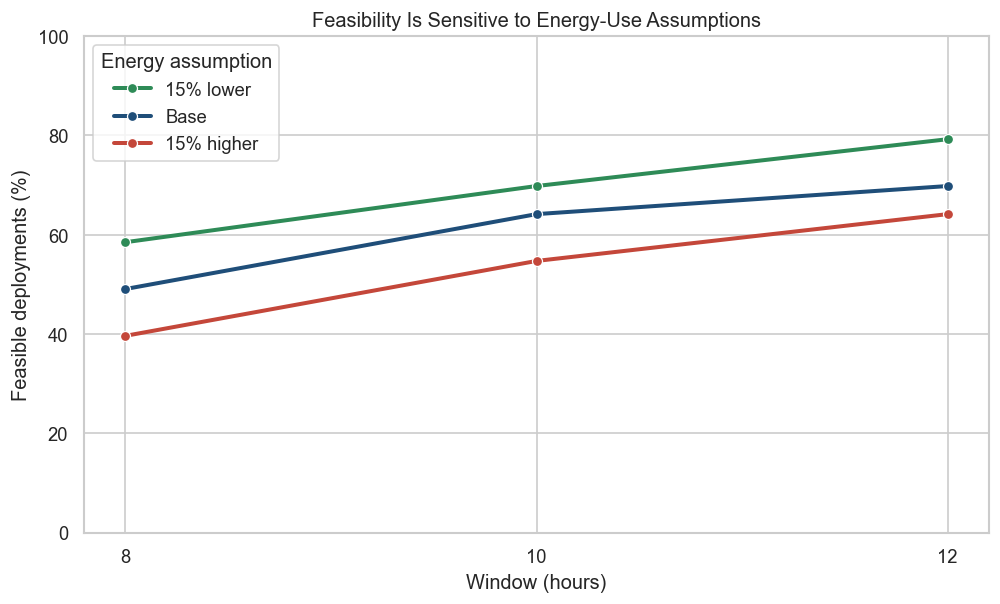

In [14]:
#Test lower and higher energy use for the primary cohort
energy_sensitivity_rows = []
for multiplier, label in [(0.85, "15% lower"), (1.00, "Base"), (1.15, "15% higher")]:
    for window_hours in charging_windows:
        effective_port_kwh = 19.2 * window_hours * scheduling_factor
        feasible = (
            deployment_summary["maximum_vehicle_grid_kwh"] * multiplier
            <= effective_port_kwh
        ) & (
            np.ceil(
                deployment_summary["planning_grid_kwh"] * multiplier
                / effective_port_kwh
            ) <= deployment_summary["vehicle_count"]
        )
        energy_sensitivity_rows.append({
            "Energy assumption": label,
            "Window (hours)": window_hours,
            "Feasible deployments (%)": 100 * feasible.mean()
        })

energy_sensitivity = pd.DataFrame(energy_sensitivity_rows)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.lineplot(
    data=energy_sensitivity, x="Window (hours)",
    y="Feasible deployments (%)", hue="Energy assumption",
    hue_order=["15% lower", "Base", "15% higher"], marker="o",
    linewidth=2.4, palette=["#2E8B57", "#1F4E79", "#C4473A"], ax=ax
)
ax.set_title("Feasibility Is Sensitive to Energy-Use Assumptions")
ax.set_ylim(0, 100)
ax.set_xticks(charging_windows)
fig.tight_layout()
fig.savefig(figure_dir / "05_operationally_suited_energy_sensitivity.png", bbox_inches="tight")
plt.show()

At 10 hours and 19.2 kilowatts, the primary cohort’s screening-feasible share is **64.2%** under the base energy assumptions. It rises to **69.8%** when assumed energy use falls by 15% and falls to **54.7%** when assumed energy use rises by 15%. Using the earlier operational-suitability results narrows the vehicles included in the infrastructure analysis, but it doesn’t remove the need for vehicle-specific efficiency data, actual schedules, and site validation.

## Technical Conclusion

* The operational-suitability rules from the earlier project are reapplied directly instead of assigning suitability from a vehicle’s vocation.
* The analysis retains 433 vehicles after applying the three-day data-quality rule.
* The vehicle-level majority rule selects 373 vehicles whose recorded operations are consistently favorable for electrification.
* The primary charging cohort contains 53 deployments, compared with 57 deployments in the broader all-vehicle comparison.
* Both cohorts contain 34 screening-feasible deployments under the 10-hour baseline.
* The screening-feasible rate increases from 59.6% in the broader comparison to 64.2% in the primary cohort because the denominator decreases from 57 to 53 deployments.
* Deployment 27 leaves the analysis even though it was screening-feasible in the broader comparison because none of its vehicles pass the majority rule.
* Deployment 50 changes from constrained to screening-feasible after its selected vehicle count falls from three to two and its planning energy decreases from approximately 424.9 to 232.6 kilowatt-hours.
* These two deployment-level changes offset each other, which explains why the number of screening-feasible deployments remains 34.
* The lower median energy in the primary cohort is partly expected because daily mileage influences both the operational-suitability screen and the charging-energy calculation. It shouldn’t be treated as independent proof that the earlier screen is accurate.
* Operationally suitable describes how a vehicle is used. Screening-feasible means a deployment passes the aggregate-energy, highest-demand-vehicle, and port-count rules. It doesn’t guarantee a workable vehicle-by-vehicle charging schedule, sufficient electrical capacity, accessible parking, or an acceptable construction cost.

## Reproducibility and Use

The notebook stores all thresholds, formulas, class-level energy factors, mappings, and cost assumptions in visible cells. The five operational-suitability rules come from the earlier project, while the vehicle-level majority rule and charging assumptions are introduced for the current infrastructure analysis.

The notebook runs the charging model for both the primary cohort and the broader group of quality-eligible vehicles. This preserves the comparison needed to measure how focusing on operationally suitable vehicles changes the infrastructure results.

Figures are saved to `figures_operationally_suited`. Replacing an assumption and rerunning the notebook updates the tables and figures, although the written interpretation should also be reviewed whenever the results change.

The results should be used as an early screening tool. A real project still requires vehicle-specific energy data, depot arrival and departure schedules, an explicit vehicle-to-port charging schedule, utility review, electrical engineering, parking and accessibility review, code compliance, and contractor pricing.

## References

Argonne National Laboratory. (n.d.). *AFLEET tool*. https://afleet.esia.anl.gov/

Duran, A., Burton, E., Kelly, K., & Walkowicz, K. (2014). *Fleet DNA project: Data dictionary for public download files* (NREL/TP-5400-62572). National Renewable Energy Laboratory.

Lustbader, J., Kotz, A., Walkowicz, K., Kelly, K., & Duran, A. (2016). *Fleet DNA* [Data set]. National Renewable Energy Laboratory. https://doi.org/10.7799/1828177

U.S. Department of Energy, Alternative Fuels Data Center. (n.d.). *Electric vehicle charging stations*. https://afdc.energy.gov/fuels/electricity-stations

U.S. Department of Energy, Alternative Fuels Data Center. (n.d.). *Procurement and installation for electric vehicle charging infrastructure*. https://afdc.energy.gov/fuels/electricity-infrastructure-development
